## Import

In [27]:
import numpy as np
import scipy
from scipy import signal
from scipy.signal import hilbert
from scipy import integrate
from pathlib import Path

try:
    from scipy.integrate import simps
except ImportError:
    from scipy.integrate import simpson

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

import warnings
import re
import matplotlib.image as mpimg
import os
import shutil
import csv
import glob
import subprocess

from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'serif'
import matplotlib


# VERY CAREFULLY not to delete other folders!
if os.path.isdir("thesis_plots"):
    shutil.rmtree("thesis_plots")
    print("thesis_plots folder is deleted and created again")
    print(" ")

os.makedirs("thesis_plots", exist_ok=True)

os.makedirs("thesis_plots/energy", exist_ok=True)
os.makedirs("thesis_plots/energy/z", exist_ok=True)
os.makedirs("thesis_plots/energy/z/pdf", exist_ok=True)
os.makedirs("thesis_plots/energy/z/png", exist_ok=True)

os.makedirs("thesis_plots/energy/x", exist_ok=True)
os.makedirs("thesis_plots/energy/x/pdf", exist_ok=True)
os.makedirs("thesis_plots/energy/x/png", exist_ok=True)


os.makedirs("thesis_plots/current", exist_ok=True)
os.makedirs("thesis_plots/current/z", exist_ok=True)
os.makedirs("thesis_plots/current/z/pdf", exist_ok=True)
os.makedirs("thesis_plots/current/z/png", exist_ok=True)

os.makedirs("thesis_plots/current/x", exist_ok=True)
os.makedirs("thesis_plots/current/x/pdf", exist_ok=True)
os.makedirs("thesis_plots/current/x/png", exist_ok=True)

os.makedirs("thesis_plots/hhg", exist_ok=True)
os.makedirs("thesis_plots/hhg/z", exist_ok=True)
os.makedirs("thesis_plots/hhg/z/pdf", exist_ok=True)
os.makedirs("thesis_plots/hhg/z/png", exist_ok=True)

os.makedirs("thesis_plots/hhg/x", exist_ok=True)
os.makedirs("thesis_plots/hhg/x/pdf", exist_ok=True)
os.makedirs("thesis_plots/hhg/x/png", exist_ok=True)

os.makedirs("thesis_plots/cco", exist_ok=True)
os.makedirs("thesis_plots/cco/pdf", exist_ok=True)
os.makedirs("thesis_plots/cco/png", exist_ok=True)

os.makedirs("thesis_plots/drude", exist_ok=True)
os.makedirs("thesis_plots/drude/pdf", exist_ok=True)
os.makedirs("thesis_plots/drude/png", exist_ok=True)


thesis_plots folder is deleted and created again
 


## get tree

In [28]:
result = subprocess.run(
    ["find", ".", "-mindepth", "6", "-maxdepth", "6", "-type", "d"],
    cwd="all_data/main",
    capture_output=True,
    text=True
)

# print(result.stdout)

all_data_folders = [
    line[2:] if line.startswith("./") else line
    for line in result.stdout.strip().split("\n")
]

# print(all_data_folders)

tree = {}

for path in all_data_folders:
    parts = path.split("/")
    
    levels = parts[:5]              # 5 уровней вложенности
    full_folder_name = path         # значение
    
    current = tree
    
    for part in levels[:-1]:        # идём до 4-го уровня
        current = current.setdefault(part, {})
    
    # 5-й уровень → присваиваем строку
    current[levels[-1]] = full_folder_name

# print(tree)

# tree['1eV']['sigma']['21fs']['4d10']['1d12']
# exists = tree.get('1eV', {}).get('sigma', {}).get('21fs', {}).get('4d10', {}).get('1d12') is not None

In [223]:
folder1 = 'all_data/main/'+tree['1eV']['sigma']['21fs']['4d10']['1d12']
folder2 = 'all_data/main/'+tree['1eV']['amorphous']['21fs']['4d10']['1d12']


folder3 = 'all_data/main/'+tree['1.5eV']['sigma']['21fs']['4d10']['5d11']
folder4 = []
if(tree.get('1.5eV', {}).get('amorphous', {}).get('21fs', {}).get('4d10', {}).get('5d11') is not None):
    folder4 = 'all_data/main/'+tree['1.5eV']['amorphous']['21fs']['4d10']['5d11']

folder5 = 'all_data/main/'+tree['2eV']['sigma']['21fs']['4d10']['6d11']
folder6 = 'all_data/main/'+tree['2eV']['amorphous']['21fs']['4d10']['6d11']

main_folders=[folder1, folder2, folder3, folder4, folder5, folder6]

folder7 = 'all_data/main/'+tree['1.5eV']['sigma']['12fs']['9d10']['5d11']
folder8 = 'all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

folder9 = 'all_data/main/'+tree['1eV']['sigma']['21fs']['1.5d11']['1d12']

## energy

### funcs

In [478]:
def blue_red_gradient(n):
    """
    Возвращает список из n цветов (hex),
    создающих линейный градиент от синего к красному.
    """
    colors = []
    
    for i in range(n):
        t = i / (n - 1)  # параметр от 0 до 1
        
        r = t            # красный растёт
        g = 0            # зелёный фиксирован
        b = 1 - t        # синий убывает
        
        colors.append(to_hex((r, g, b)))
    
    return colors

In [479]:
def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

In [480]:
def extract_amorphous_value(name):
    tokens = name.split("_")
    for i, token in enumerate(tokens):
        if token == "amorphous" and i + 1 < len(tokens):
            return float(tokens[i + 1])

In [481]:
def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    if match:
        return float(match.group(1).replace("d", "e"))

### plots

In [41]:
main_folders

['all_data/main/1eV/sigma/21fs/4d10/1d12/all_data_v2_Jan28_1eV_21fs_sigma',
 'all_data/main/1eV/amorphous/21fs/4d10/1d12/all_data_v2_Jan30_1eV_21fs_amorphous',
 'all_data/main/1.5eV/sigma/21fs/4d10/5d11/all_data_v2_Feb14_1.5eV_21fs_sigma',
 [],
 'all_data/main/2eV/sigma/21fs/4d10/6d11/all_data_v2_Feb13_2eV_21fs_sigma',
 'all_data/main/2eV/amorphous/21fs/4d10/6d11/all_data_v2_Feb16_2eV_21fs_amorphous']

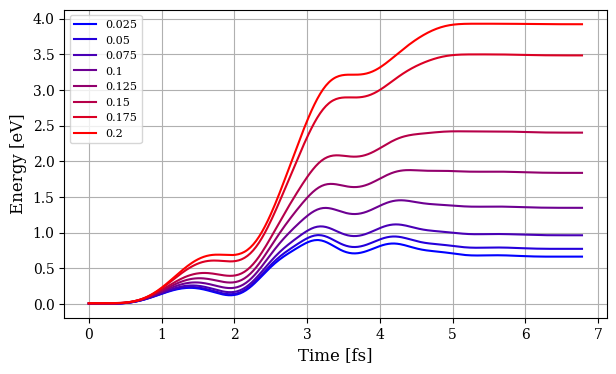

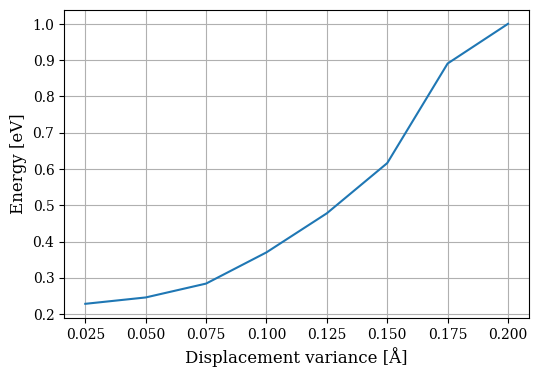

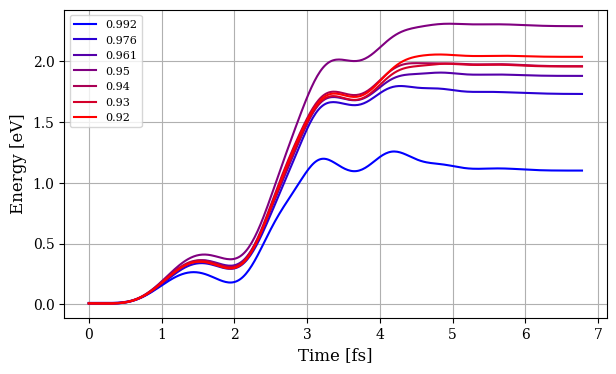

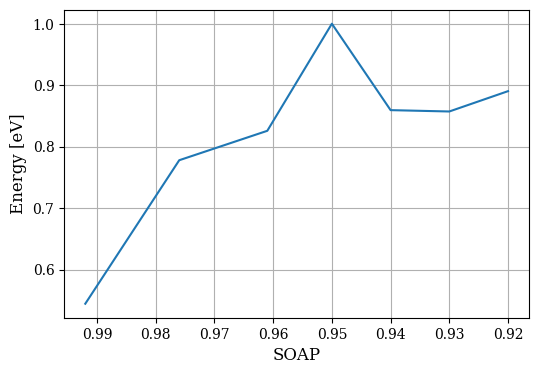

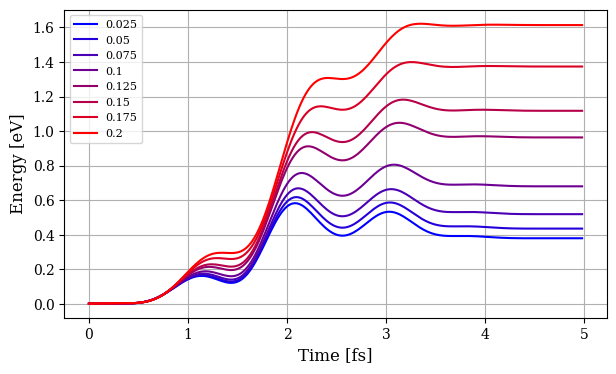

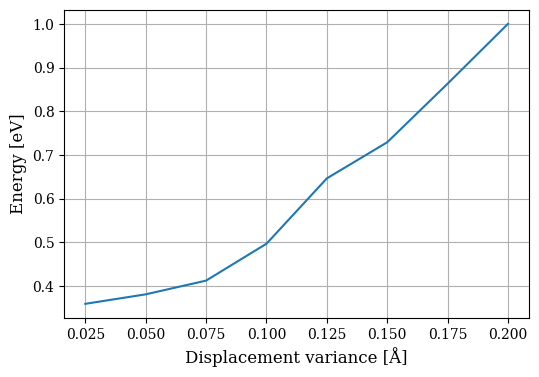

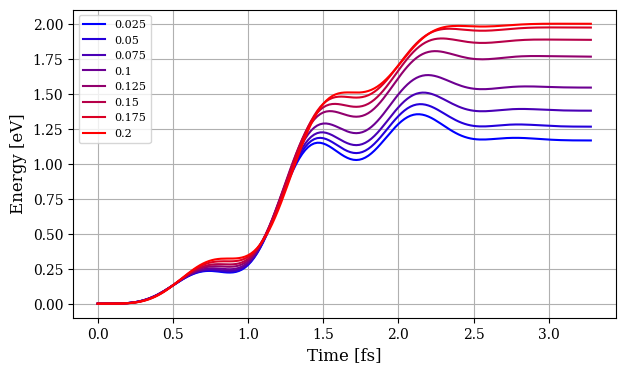

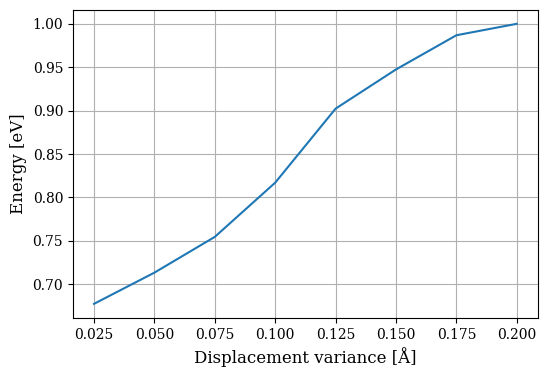

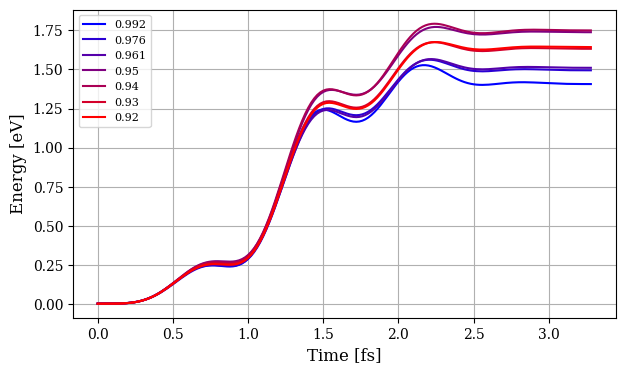

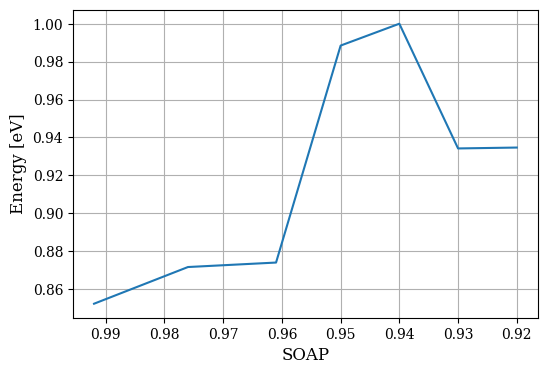

In [42]:
for main_folder in main_folders:
    if(main_folder):

        files_path = Path(main_folder+'/current_energy/data')
        filenames_arr=[]
        
        for item in files_path.iterdir():
            filename = Path(item).name
            # print(filename)
            filenames_arr.append(filename)
        
        filenames_arr = sorted(filenames_arr)

        if '1eV' in main_folder:
            t1, t2 = (385, 725)
        if '1.5eV' in main_folder:
            t1, t2 = (425, 675)
        if '2eV' in main_folder:
            t1, t2 = (460, 625)
        
        colors = blue_red_gradient(len(filenames_arr))

        plt.figure(figsize=(7, 4))
        plt.grid()
        plt.xlabel('Time [fs]', fontsize=12)
        plt.ylabel('Energy [eV]', fontsize=12)

        disorders=[]
        final_energies=[]
        j=0
        for f in filenames_arr:
            if 'amorphous' in f:
                label_name=extract_amorphous_value(f[:-4])
            else: label_name=extract_s_num(f[:-4])
            # print(extract_s_num(f))
            df = pd.read_csv(main_folder + "/current_energy/data/" + f, comment='#')
            plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j], label=label_name)
            final_energies.append(max(df['En_both_z']))
            disorders.append(label_name)
            j=j+1
            
        plt.legend(fontsize=8)

        plt.figure(figsize=(6, 4))
        plt.plot(disorders, np.array(final_energies)/max(final_energies))
        if 'amorphous' in main_folder:
            plt.gca().invert_xaxis()
            plt.xlabel('SOAP', fontsize=12)
        else: plt.xlabel('Displacement variance [Å]', fontsize=12)
        plt.grid()
        plt.ylabel('Energy [eV]', fontsize=12)

In [9]:
max(final_energies)

1.79200307381637

### z

#### averaging error

In [482]:
amorph_disorders = [0.992, 0.976, 0.961, 0.95, 0.94, 0.93, 0.92]
sigma_disorders= [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

In [503]:
# plt.figure(figsize=(7, 4))
# plt.grid()

# all_mean_vals=[]

# for main_folder in [folder3, folder7]:

#     files_path = Path(main_folder+'/current_energy/data')
#     filenames_arr=[]
    
#     for item in files_path.iterdir():
#         filename = Path(item).name
#         # print(filename)
#         filenames_arr.append(filename)
    
#     filenames_arr = sorted(filenames_arr)

#     if '21fs' in main_folder:
#         t1, t2 = (425, 640)

#     if '12fs' in main_folder:
#         t1, t2 = (200, 415)
    
#     colors = blue_red_gradient(len(filenames_arr))
#     if not ('amorphous' in filenames_arr[0]):
#         colors=blue_red_gradient(6)

#     plt.xlabel('Time [fs]', fontsize=12)
#     plt.ylabel('Energy [eV]', fontsize=12)

#     disorders=[]
#     final_energies=[]
#     j=0
#     mean_vals=[]
#     for f in filenames_arr:

#         if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
        
#             if 'amorphous' in f:
#                 label_name=extract_amorphous_value(f[:-4])
#             else: label_name=extract_s_num(f[:-4])
#             # print(extract_s_num(f))
#             df = pd.read_csv(main_folder + "/current_energy/data/" + f, comment='#')
#             if main_folder == folder3:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j], label=label_name)
#             else:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j])
#             final_energies.append(max(df['En_both_z']))
#             disorders.append(label_name)
#             j=j+1
#             mean_vals.append(np.mean(df['En_both_z'][t1:t2]))

#     all_mean_vals.append(mean_vals)


#     plt.legend(fontsize=9)

# # 1.5 eV pump 5d11 

In [504]:
# plt.plot(sigma_disorders[:6], abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1]))), color='b')
# plt.grid()
# print(np.mean(abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))
# print(np.std(abs(abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))

In [505]:
# plt.figure(figsize=(7, 4))
# plt.grid()

# all_mean_vals=[]

# for main_folder in [folder1, folder9]:

#     files_path = Path(main_folder+'/current_energy/data')
#     filenames_arr=[]
    
#     for item in files_path.iterdir():
#         filename = Path(item).name
#         # print(filename)
#         filenames_arr.append(filename)
    
#     filenames_arr = sorted(filenames_arr)

#     if '21fs' in main_folder:
#         t1, t2 = (415, 660)

#     if '12fs' in main_folder:
#         t1, t2 = (190, 435)
    
#     colors = blue_red_gradient(len(filenames_arr))
#     if not ('amorphous' in filenames_arr[0]):
#         colors=blue_red_gradient(6)

#     plt.xlabel('Time [fs]', fontsize=12)
#     plt.ylabel('Energy [eV]', fontsize=12)

#     disorders=[]
#     final_energies=[]
#     j=0
#     mean_vals=[]
#     for f in filenames_arr:

#         if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
        
#             if 'amorphous' in f:
#                 label_name=extract_amorphous_value(f[:-4])
#             else: label_name=extract_s_num(f[:-4])
#             # print(extract_s_num(f))
#             df = pd.read_csv(main_folder + "/current_energy/data/" + f, comment='#')
#             if main_folder == folder1:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j], label=label_name)
#             else:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j])
#             final_energies.append(max(df['En_both_z']))
#             disorders.append(label_name)
#             j=j+1
#             mean_vals.append(np.mean(df['En_both_z'][t1:t2]))

#     all_mean_vals.append(mean_vals)
#     plt.legend(fontsize=9)

# # 1 eV pump 1d12 Jan28, Jan26

In [506]:
# plt.plot(sigma_disorders[:6], abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1]))), color='b')
# plt.grid()
# print(np.mean(abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))
# print(np.std(abs(abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))

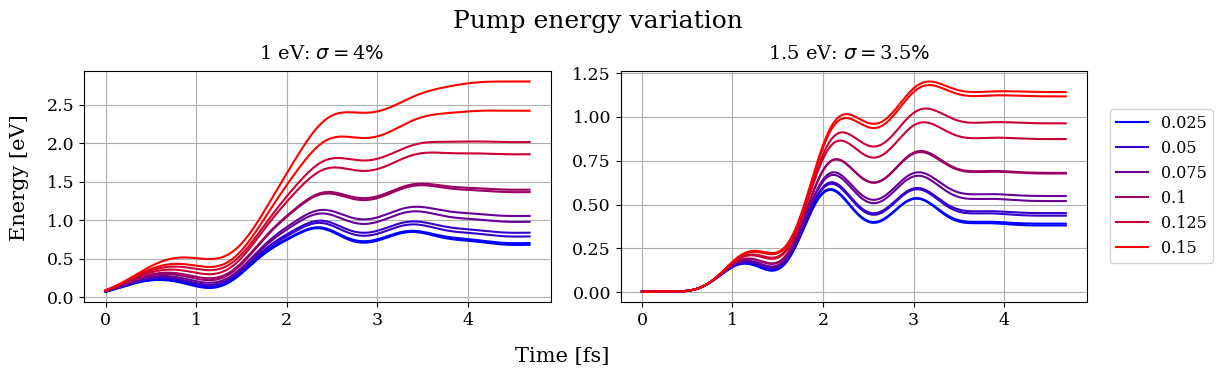

In [521]:
figsize = (12, 4)

tick_size = 12.5
axis_label_size = 15
suptitle_size = 18
legend_fontsize = 11.5
col_title_size = 14

suptitle_text = "Pump energy variation"

fig, axes = plt.subplots(1, 2, figsize=figsize)


groups = [
    [folder1, folder9],
    [folder3, folder7]
]

for ax, folder_group in zip(axes, groups):

    ax.grid()
    ax.tick_params(labelsize=tick_size)

    for main_folder in folder_group:

        files_path = Path(main_folder) / 'current_energy' / 'data'
        filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

        if '21fs' in main_folder:
            t1, t2 = (425, 660)
        if '12fs' in main_folder:
            t1, t2 = (200, 435)

        colors = blue_red_gradient(len(filenames_arr))
        if not ('amorphous' in filenames_arr[0]):
            colors=blue_red_gradient(6)

        
        for j, f in enumerate(filenames_arr):

            if 'amorphous' in f:
                label_name = extract_amorphous_value(f[:-4])
            else:
                label_name = extract_s_num(f[:-4])

            df = pd.read_csv(files_path / f, comment='#')

            if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
                ax.plot(
                    df['time'][t1:t2] - df['time'][t1],
                    df['En_both_z'][t1:t2],
                    color=colors[j],
                    label=label_name if main_folder == folder_group[0] else None
                )

# ---------- Общая легенда справа ----------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(0.92, 0.48),
    fontsize=legend_fontsize,
    frameon=True
)

# ---------- ЕДИНЫЕ подписи ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.03, x=0.47)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, y=0.92)


# Оставляем место справа и сверху
plt.tight_layout(rect=(0, 0, 0.92, 0.90))

# ---------- Подписи над столбцами ----------
col_titles = [r"1 eV: $\sigma$$=$4$\%$", r"1.5 eV: $\sigma$$=$3.5$\%$"]

fig.canvas.draw()  # теперь AFTER tight_layout

for ax, title in zip(axes, col_titles):
    bbox = ax.get_position()
    x_center = bbox.x0 + bbox.width / 2
    y_top = bbox.y1 + 0.02   # можно чуть подвинуть

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=col_title_size
    )

fig.subplots_adjust(wspace=0.15)

plt.savefig("thesis_plots/energy/z/png/" + 'pump_energy_variation.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_energy_variation.pdf', bbox_inches="tight")

plt.show()
plt.close()

In [502]:
# для 8 точек
# для 1 эВ -- std -- 6%
# для 1.5 эВ -- std -- 3.5%
# для 2 эВ -- std -- 2% (допустим)

# для 6 точек
# для 1 эВ -- std -- 3.5%
# для 1.5 эВ -- std -- 3.5%
# для 2 эВ -- std -- 2% (допустим)

#### full

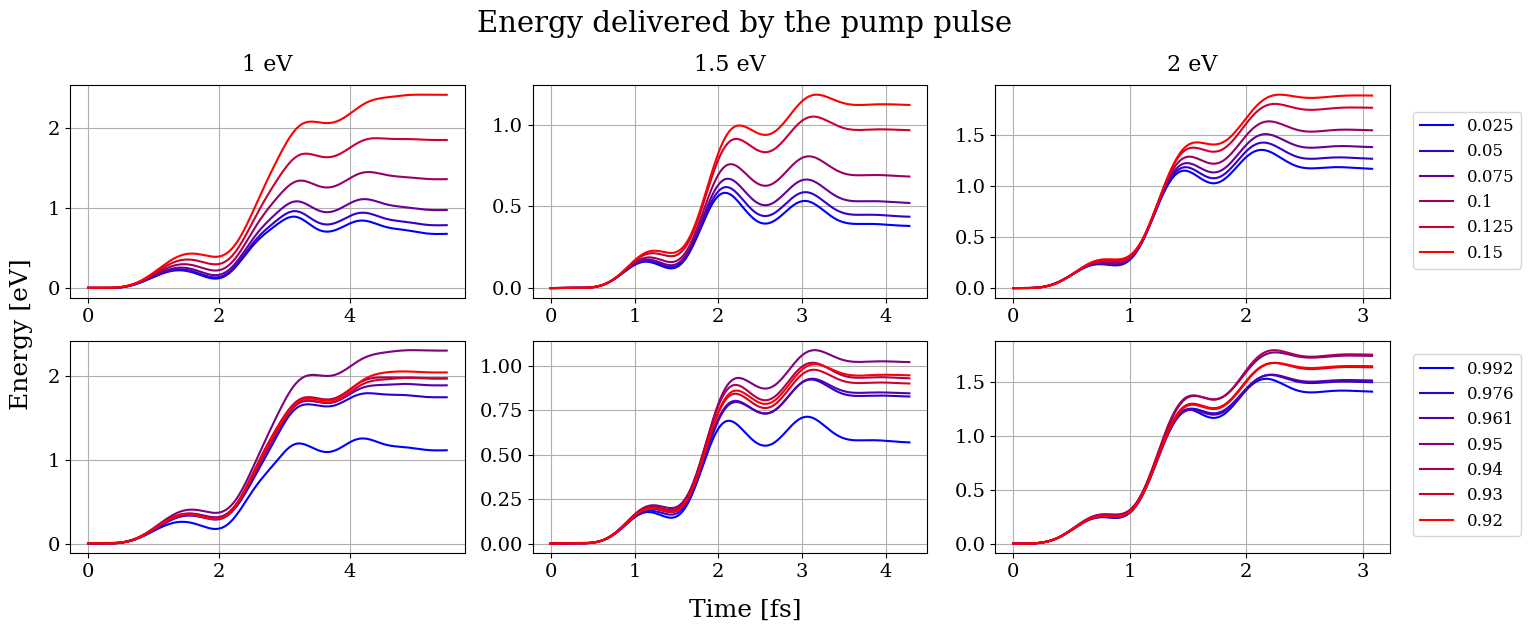

In [514]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Energy delivered by the pump pulse'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (385, 660)
    if '1.5eV' in main_folder:
        t1, t2 = (425, 640)
    if '2eV' in main_folder:
        t1, t2 = (460, 615)
        
    if '12fs' in main_folder:
        t1, t2 = (200, 415)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):

        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
        
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')
    
            ax.plot(
                df['time'][t1:t2] - df['time'][t1],
                df['En_both_z'][t1:t2],
                color=colors[j],
                label=label_name
            )

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.02)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/energy/z/png/" + 'pump_energy_comparison_pump_pulse.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_energy_comparison_pump_pulse.pdf', bbox_inches="tight")

plt.show()
plt.close()

#### final vals

In [373]:
amorph_disorders = [0.992, 0.976, 0.961, 0.95, 0.94, 0.93, 0.92]
sigma_disorders= [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

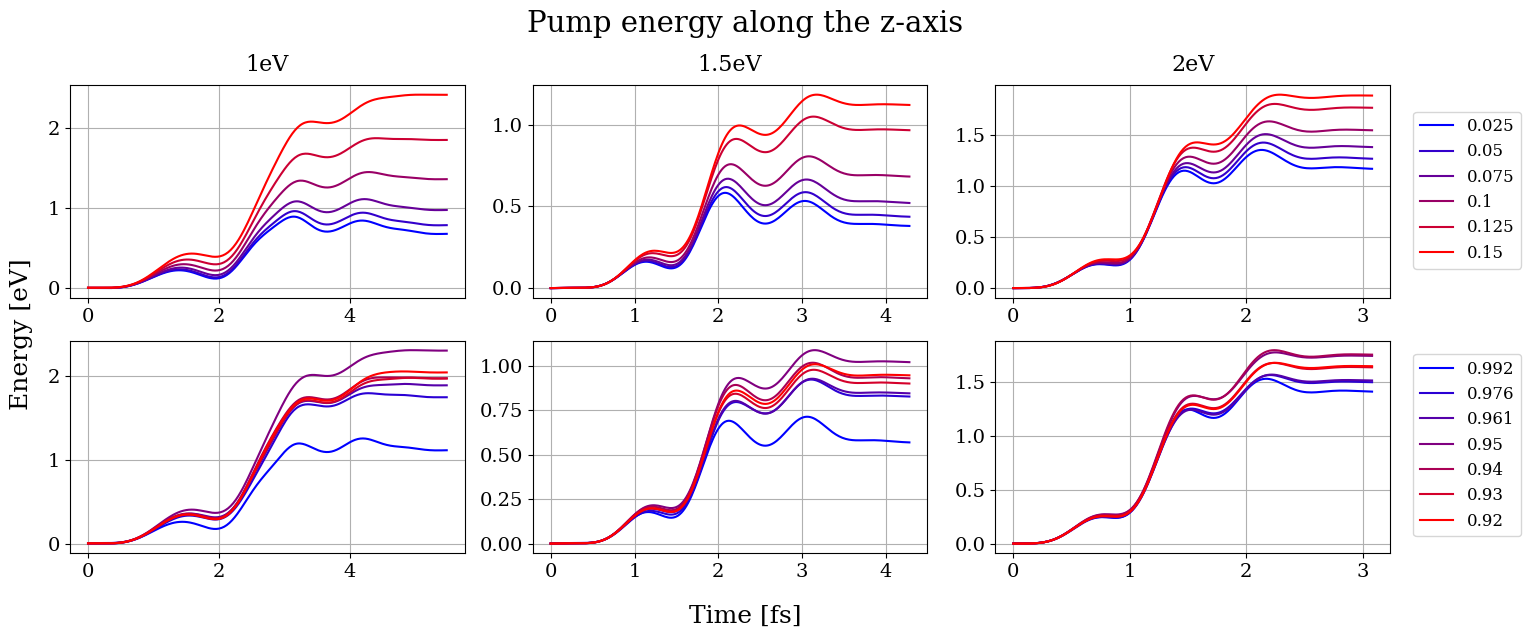

In [523]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Pump energy along the z-axis'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

all_final_energy_z_vals=[]

disorders_sigma=[]
disorders_amorphous=[]

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (385, 660)
    if '1.5eV' in main_folder:
        t1, t2 = (425, 640)
    if '2eV' in main_folder:
        t1, t2 = (460, 615)
        
    if '12fs' in main_folder:
        t1, t2 = (200, 415)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    
    final_energy_z_vals=[]
    for j, f in enumerate(filenames_arr):
    
        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')
    
            final_energy_z_vals.append(np.array(df['En_both_z'])[-1])
            if 'amorphous' in f:
                disorders_amorphous.append(label_name)
            else: 
                disorders_sigma.append(label_name)
            
            ax.plot(
                df['time'][t1:t2] - df['time'][t1],
                df['En_both_z'][t1:t2],
                color=colors[j],
                label=label_name, linewidth=1.5
            )

    ax.tick_params(labelsize=tick_size)
    # print(main_folder)
    # print(np.round(final_energy_z_vals, 2))
    all_final_energy_z_vals.append(final_energy_z_vals/max(final_energy_z_vals))

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1eV', '1.5eV', '2eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

# plt.savefig("thesis_plots/energy/z/png/" + 'pump_energy_comparison_pump_pulse.png', dpi=200, bbox_inches="tight")
# plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_energy_comparison_pump_pulse.pdf', bbox_inches="tight")
plt.show()
plt.close()

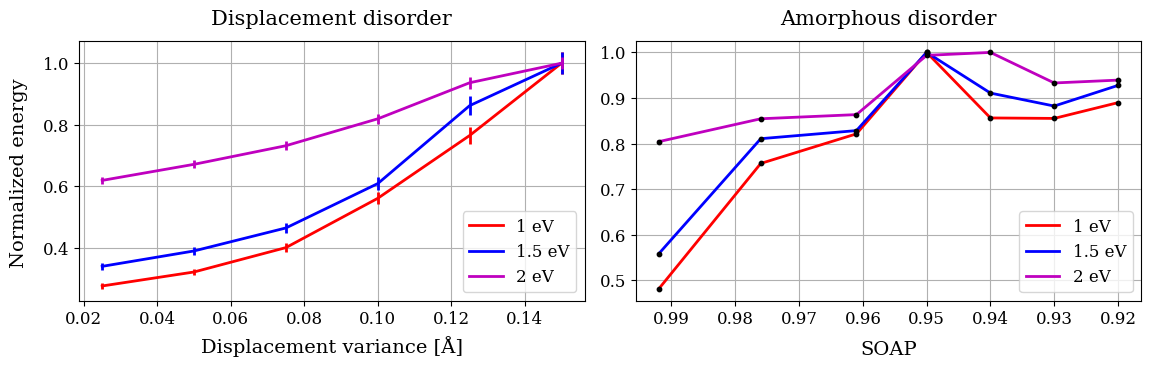

In [527]:

# =======================
# Размеры шрифтов
# =======================

label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 12
column_title_fontsize = 15
suptitle_fontsize = 16

# =======================
# Subplots
# =======================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1, ax2 = axes

# =======================
# Первый график
# =======================

ax1.set_xlabel('Displacement variance [Å]', fontsize=label_fontsize, labelpad=6)
ax1.grid()
ax1.set_title('Displacement disorder', fontsize=column_title_fontsize, y=1.03)

ax1.plot(sigma_disorders[:6], all_final_energy_z_vals[0], 'r', label='1 eV', linewidth=2)
ax1.errorbar(
    sigma_disorders[:6],
    all_final_energy_z_vals[0],
    yerr=0.035 * all_final_energy_z_vals[0],
    fmt='none',
    color='r', elinewidth=2
)

ax1.plot(sigma_disorders[:6], all_final_energy_z_vals[2], 'b', label='1.5 eV', linewidth=2)
ax1.errorbar(
    sigma_disorders[:6],
    all_final_energy_z_vals[2],
    yerr=0.035 * all_final_energy_z_vals[2],
    fmt='none',
    color='b', elinewidth=2
)

ax1.plot(sigma_disorders[:6], all_final_energy_z_vals[4], 'm', label='2 eV', linewidth=2)
ax1.errorbar(
    sigma_disorders[:6],
    all_final_energy_z_vals[4],
    yerr=0.02 * all_final_energy_z_vals[4],
    fmt='none',
    color='m', elinewidth=2
)

ax1.legend(fontsize=legend_fontsize, loc='lower right')


# =======================
# Второй график
# =======================

ax2.set_xlabel('SOAP', fontsize=label_fontsize, labelpad=9)
ax2.grid()
ax2.set_title('Amorphous disorder', fontsize=column_title_fontsize, y=1.03)
ax2.invert_xaxis()

ax2.plot(amorph_disorders, all_final_energy_z_vals[1], 'r', label='1 eV', linewidth=2)
ax2.scatter(amorph_disorders, all_final_energy_z_vals[1], color='black', s=10, zorder=3)

ax2.plot(amorph_disorders, all_final_energy_z_vals[3], 'b', label='1.5 eV', linewidth=2)
ax2.scatter(amorph_disorders, all_final_energy_z_vals[3], color='black', s=10, zorder=3)

ax2.plot(amorph_disorders, all_final_energy_z_vals[5], 'm', label='2 eV', linewidth=2)
ax2.scatter(amorph_disorders, all_final_energy_z_vals[5], color='black', s=10, zorder=3)

ax2.legend(fontsize=legend_fontsize, loc='lower right')


# =======================
# ОДНА подпись Y на всю фигуру
# =======================

fig.text(
    0.045, 0.5,
    'Normalized energy',
    va='center',
    rotation='vertical',
    fontsize=label_fontsize
)

# =======================
# Общий заголовок
# =======================

# fig.suptitle(
#     'Pump Energy vs Disorder Metrics',
#     fontsize=suptitle_fontsize
# )

# =======================
# Размеры тиков
# =======================

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

plt.tight_layout(rect=[0.06, 0, 1, 0.95])  # чтобы не обрезалось


plt.savefig("thesis_plots/energy/z/png/" + 'pump_pulse_photoinjection_energy_final_vals.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_pulse_photoinjection_energy_final_vals.pdf', bbox_inches="tight")

plt.show()
plt.close()

### x

In [100]:
energy_x_folders = [folder5, folder6, folder7, folder8]

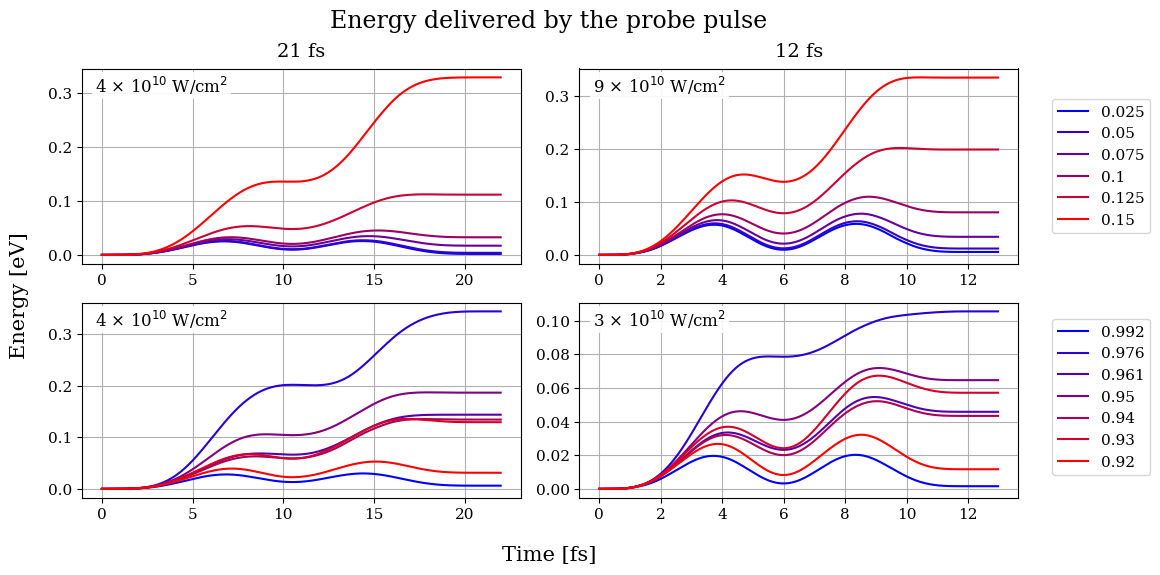

In [529]:
# ================= НАСТРОЙКИ =================
figsize = (11, 5.5)

# размеры текста
col_title_size = 14
axis_label_size = 15
tick_size = 11
suptitle_size = 17

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Energy delivered by the probe pulse'
suptitle_x = 0.5
suptitle_y = 1.02

# легенды справа (по одной на строку)
legend_fontsize = 11
legend_x = 0.95
legend_y_top = 0.735
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 2, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(energy_x_folders):

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '12fs' in main_folder:
        t1, t2 = (0, 650)
    if '21fs' in main_folder:
        t1, t2 = (0, 1100)


    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')
    
            ax.plot(
                df['time'][t1:t2] - df['time'][t1],
                df['En_probe_x'][t1:t2],
                color=colors[j],
                label=label_name
            )

    # print(extract_p(f))



    # --- подпись I0 в левом верхнем углу текущей оси ---
    I0 = extract_p(f)  # f здесь = последний файл из filenames_arr

    # экспоненциальная форма: value * 10^{power}, value с точностью до 0 знаков

    power = int(np.floor(np.log10(abs(I0))))
    value = I0 / (10 ** power)
    value = int(np.round(value))  # 0 знаков после запятой

    # на всякий случай нормализация, если округление дало 10
    if abs(value) == 10:
        value = int(np.sign(value) * 1)
        power += 1

    # text = rf"I$_{{\mathrm{{peak}}}}$ = {value} × 10$^{{{power}}}$ W/cm$^2$"
    text = rf"{value} × 10$^{{{power}}}$ W/cm$^2$"

    ax.text(
        0.03, 0.97, text,
        transform=ax.transAxes,   # координаты внутри оси: (0..1, 0..1)
        ha='left', va='top',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2.0)
    )
    

    

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа



# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['21 fs', '12 fs']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/energy/x/png/" + 'pump_energy_comparison_probe_pulse.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/x/pdf/" + 'pump_energy_comparison_probe_pulse.pdf', bbox_inches="tight")

plt.show()
plt.close()

## current

### z

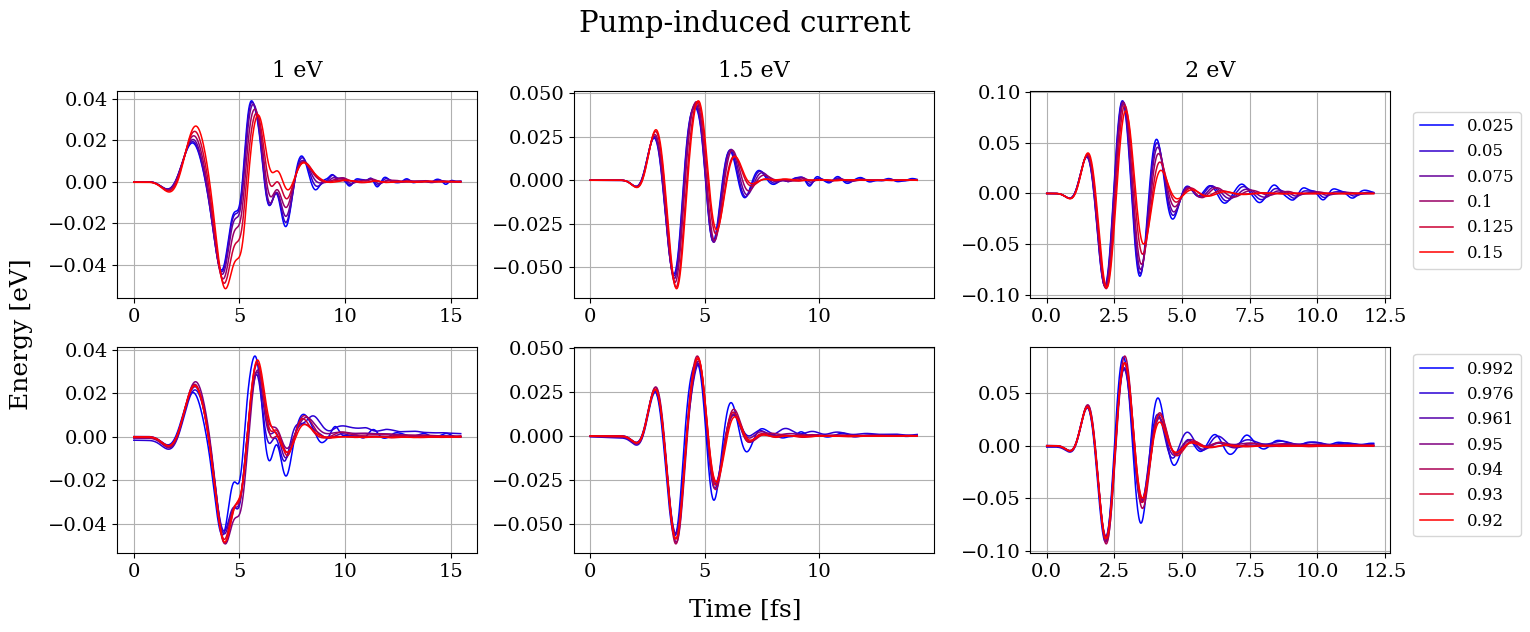

In [477]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Pump-induced current'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (285, 1060)
    if '1.5eV' in main_folder:
        t1, t2 = (325, 1040)
    if '2eV' in main_folder:
        t1, t2 = (410, 1015)
        
    if '12fs' in main_folder:
        t1, t2 = (100, 815)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
        df = pd.read_csv(files_path / f, comment='#')

        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            ax.plot(
                df['time'][t1:t2]-df['time'][t1],
                df['Jm_both_z'][t1:t2],
                color=colors[j],
                label=label_name, linewidth=1.1
            )

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.02)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/current/z/png/" + 'pump_pulse_response_comparison.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/current/z/pdf/" + 'pump_pulse_response_comparison.pdf', bbox_inches="tight")

plt.show()
plt.close()

## draft

In [310]:
# for main_folder in main_folders:
#     if(main_folder):

#         files_path = Path(main_folder+'/current_energy/data')
#         filenames_arr=[]
        
#         for item in files_path.iterdir():
#             filename = Path(item).name
#             # print(filename)
#             filenames_arr.append(filename)
        
#         filenames_arr = sorted(filenames_arr)

#         if '1eV' in main_folder:
#             t1, t2 = (385, 725)
#         if '1.5eV' in main_folder:
#             t1, t2 = (425, 675)
#         if '2eV' in main_folder:
#             t1, t2 = (460, 625)
        
#         colors = blue_red_gradient(len(filenames_arr))

#         plt.figure(figsize=(7, 4))
#         plt.grid()
#         plt.xlabel('Time [fs]', fontsize=12)
#         plt.ylabel('Energy [eV]', fontsize=12)
#         j=0
#         for f in filenames_arr:
#             if 'amorphous' in f:
#                 label_name=extract_amorphous_value(f[:-4])
#             else: label_name=extract_s_num(f[:-4])
#             # print(extract_s_num(f))
#             df = pd.read_csv(main_folder + "/current_energy/data/" + f, comment='#')
#             plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j], label=label_name)
#             j=j+1
        
#         plt.legend(fontsize=8)